In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("../data/cleaned_data.csv")

In [3]:
features = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "HeavyAtomCount",
    "NumHAcceptors",
    "NumHDonors",
    "NumRotatableBonds",
    "MolMR"
]

In [4]:
target = "Solubility"

In [5]:
X = df[features]

y = df[target]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[-0.01,-0.38,-0. ,..., 0.15, 0.07, 0.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MolWt','MolLogP','TPSA',...,'NumHDonors','NumRotatableBonds','MolMR']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.482
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [8]:
predictions = model.predict(X_test)

In [9]:
print("MAE:", mean_absolute_error(y_test, predictions))

print("RMSE:",
      mean_squared_error(
          y_test,
          predictions
      ) ** 0.5)

print("R²:", r2_score(y_test, predictions))

MAE: 1.2650913767135414
RMSE: 1.7249674311503667
R²: 0.4514825435609533


In [10]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

results.head(10)

,Actual,Predicted
1253,-5.984242,-3.681849
9930,-4.160000,-4.101504
7046,-2.283900,-3.314828
8711,-4.230000,-4.148518
6880,0.552600,-1.975464
1056,-2.153178,-2.535628
35,-4.793228,-3.735569
9682,-2.390000,-2.382110
2168,0.166535,-2.702584
6952,-1.496900,-1.925499


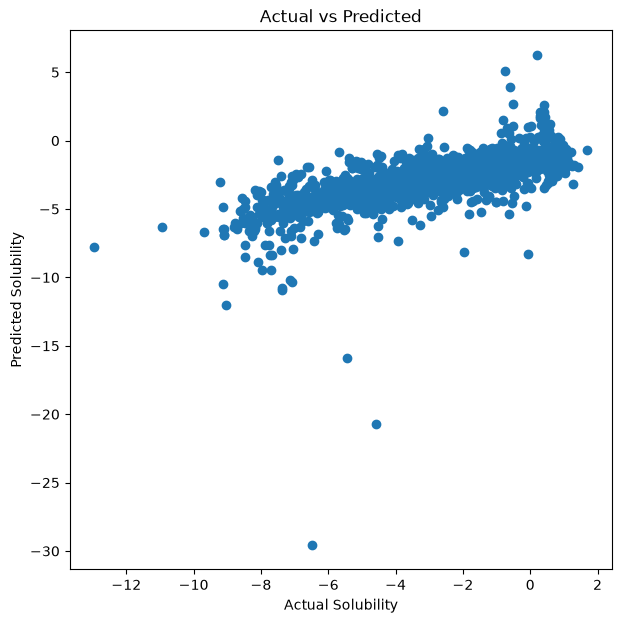

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Solubility")

plt.ylabel("Predicted Solubility")

plt.title("Actual vs Predicted")

plt.show()

In [12]:
importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

importance.sort_values(
    "Coefficient",
    ascending=False
)

,Feature,Coefficient
4,NumHAcceptors,0.167265
5,NumHDonors,0.152878
6,NumRotatableBonds,0.070386
7,MolMR,0.032079
2,TPSA,-0.000900
0,MolWt,-0.006866
3,HeavyAtomCount,-0.111978
1,MolLogP,-0.381444


In [13]:
import joblib

joblib.dump(
    model,
    "../model.pkl"
)

['../model.pkl']